In [1]:
import torch
import torch.nn as nn

# ----------------------
# 1. 你的模型预测概率（已过sigmoid，值在[0,1]）
# ----------------------
probs = torch.tensor([
    9.9413e-01, 6.8100e-01, 9.9954e-01, 7.8168e-01, 5.1743e-03, 9.9653e-01,
    1.2286e-03, 1.4521e-01, 1.0544e-03, 2.0918e-02, 9.9980e-01, 1.5688e-02,
    8.2512e-01, 1.6236e-06, 1.5716e-01, 1.0271e-04, 7.4857e-01, 7.0915e-02,
    9.9469e-01, 8.3030e-01, 9.9995e-01, 9.9900e-01, 8.9883e-01, 8.5197e-04,
    9.9998e-01, 9.9979e-01, 2.9232e-03, 1.7414e-02, 9.9680e-01, 7.7882e-01,
    4.1677e-05, 8.7651e-01, 4.9705e-03, 9.9997e-01, 9.9958e-01, 3.1001e-03,
    3.3613e-05, 2.3090e-02, 9.9454e-01, 3.7087e-03, 3.6508e-01, 5.6662e-01,
    1.1517e-02, 9.9785e-01, 9.9991e-01, 9.6004e-01, 1.0883e-02, 2.9432e-06,
    9.9995e-01, 9.9922e-01, 9.9988e-01, 5.4292e-03, 9.9882e-01, 9.9712e-01,
    5.6414e-01, 9.7862e-01, 9.4090e-01, 9.9985e-01, 9.9976e-01, 9.9975e-01,
    4.5086e-02, 9.9992e-01, 4.8334e-02, 7.6712e-01
], dtype=torch.float32)

# ----------------------
# 2. 真实标签（0/1）
# ----------------------
labels = torch.tensor([
    0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1.,
    1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0.,
    1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
    0., 0., 1., 1., 1., 0., 1., 0., 0., 0.
], dtype=torch.float32)

# ----------------------
# 3. 计算BCE Loss
# ----------------------
# 平均BCE Loss（默认）
bce_loss_mean = nn.BCELoss()
loss = bce_loss_mean(probs, labels)
print(f"平均 BCE Loss: {loss.item():.6f}")


平均 BCE Loss: 3.158982


512 512
(632, 632)


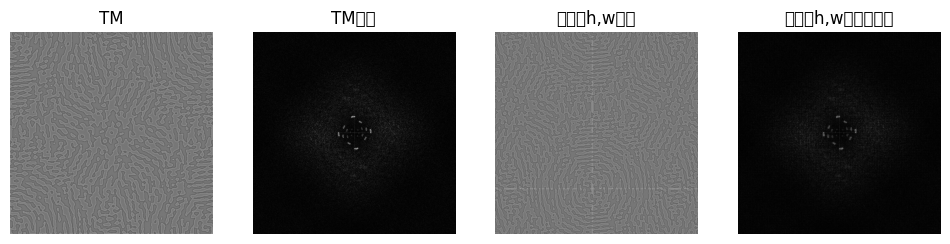

In [38]:
#读取水印模板
from re import I
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import wiener
Tm = cv2.imread("img_mask/watermark_template.png", cv2.IMREAD_GRAYSCALE)
Tm=Tm.astype(np.float32)
Tn=wiener(Tm, mysize=(5, 5)).astype(np.float32)
Tm=Tm-Tn

(h, w) = Tm.shape
print(h, w)
fftimg=np.abs(fftshift(fft2(Tm.astype(np.float32))))
# fftimg=20*np.log(fftimg+1e-10)
fftimg=cv2.normalize(fftimg, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
#将TM平铺2*2
Tm2 = np.tile(Tm, (2, 2))
#随机裁取TM2的h,w大小
crop_block_y=np.random.randint(0, h//2)
crop_block_x=np.random.randint(0, w//2)
crop_block = Tm2[crop_block_y:crop_block_y+h+120, crop_block_x:crop_block_x+w+120]
print(crop_block.shape)
#crop_block的频谱
crop_block_fft=np.abs(fftshift(fft2(crop_block.astype(np.float32))))
# crop_block_fft=20*np.log(crop_block_fft+1e-10)
crop_block_fft=cv2.normalize(crop_block_fft, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)



plt.figure(figsize=(12, 4))
#显示TM2
ax = plt.subplot(1, 4, 1)

ax.imshow(Tm, cmap="gray")
ax.set_title("TM")
ax.axis("off")
#显示TM2的频谱
ax = plt.subplot(1, 4, 2)
ax.imshow(fftimg, cmap="gray")
ax.set_title("TM频谱")
ax.axis("off")
#显示裁取的h,w大小
ax = plt.subplot(1, 4, 3)
ax.imshow(crop_block, cmap="gray")
ax.set_title("裁取的h,w大小")
ax.axis("off")
#显示裁取的h,w大小的频谱
ax = plt.subplot(1, 4, 4)
ax.imshow(crop_block_fft, cmap="gray")
ax.set_title("裁取的h,w大小的频谱")
ax.axis("off")
plt.show()



(512, 512, 3)
(428, 640, 3)


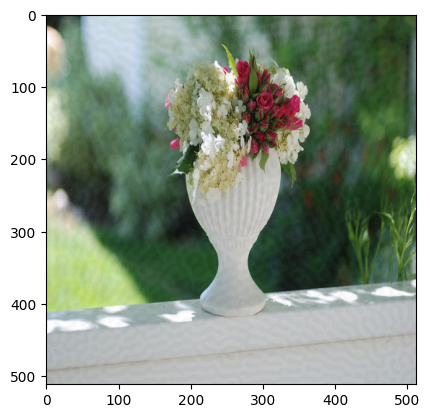

38.93604815328772


In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    return 10 * np.log10(255.0**2 / mse)
hostimg=cv2.imread('/home/ylu2024/workspace/fftmask/host_imgs/COCO_train2014_000000000030.jpg')
watermarkimg=cv2.imread('/home/ylu2024/workspace/fftmask/img_mask/message_watermark_template1.png')
print(watermarkimg.shape)
print(hostimg.shape)
watermarkimg=cv2.resize(watermarkimg, (512, 512))
hostimg=cv2.resize(hostimg, (512, 512))
alpha_embed = 0.02
newimg=hostimg*(1-alpha_embed)+watermarkimg*alpha_embed
# Convert to 8-bit unsigned integer before color conversion
newimg = np.clip(newimg, 0, 255).astype(np.uint8)
psnr=psnr(hostimg, newimg)
newimg=cv2.cvtColor(newimg, cv2.COLOR_BGR2RGB)
plt.imshow(newimg)
plt.show()
print(psnr)



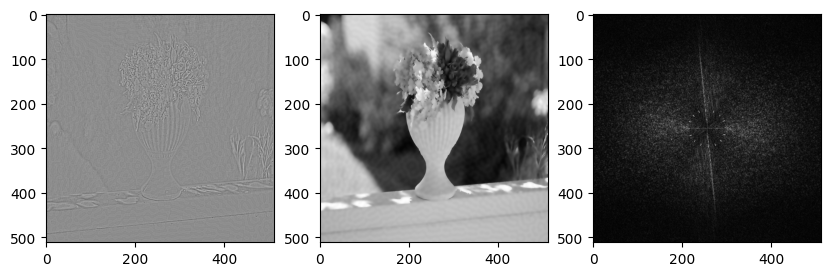

In [40]:
from scipy.signal import wiener
from numpy.fft import fft2, fftshift
import numpy as np
import matplotlib.pyplot as plt
import cv2
newing=cv2.cvtColor(newimg, cv2.COLOR_RGB2YUV)
newing=newing[:,:,0].astype(np.float32)
isimg=wiener(newing,mysize=(5,5)).astype(np.float32)
img=newing-isimg
cv2.imwrite("img.png", img.astype(np.uint8))
fftimg=np.abs(fftshift(fft2(img.astype(np.float32))))
# fftimg=20*np.log(fftimg+1e-10)
fftimg=cv2.normalize(fftimg, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
cv2.imwrite("fftimg.png", fftimg.astype(np.uint8))
plt.figure(figsize=(10,10))
ax=plt.subplot(1,3,1)
ax.imshow(img,cmap='gray')
ax=plt.subplot(1,3,2)
ax.imshow(isimg,cmap='gray')
ax=plt.subplot(1,3,3)
ax.imshow(fftimg,cmap='gray')
plt.show()



(512, 512)
(428, 640, 3)


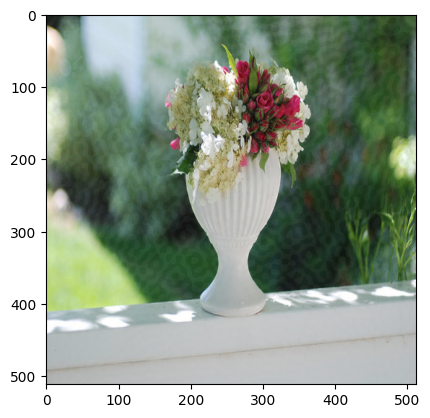

30.84483901114813


In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cwt_method import CWTWatermark
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    return 10 * np.log10(255.0**2 / mse)
cwt_watermark = CWTWatermark()
hostimg=cv2.imread('/home/ylu2024/workspace/fftmask/host_imgs/COCO_train2014_000000000030.jpg')
watermarkimg=cv2.imread('/home/ylu2024/workspace/fftmask/img_mask/message_watermark_template1.png', cv2.IMREAD_GRAYSCALE)
print(watermarkimg.shape)
print(hostimg.shape)
watermarkimg=cv2.resize(watermarkimg, (512, 512))
hostimg=cv2.resize(hostimg, (512, 512))
host_yuv = cv2.cvtColor(hostimg, cv2.COLOR_BGR2YUV)
host_y = host_yuv[:, :, 0].astype(np.float32)

Tm_float = watermarkimg.astype(np.float32) / 255.0

JND = cwt_watermark.calculate_jnd(host_y)

alpha_embed = getattr(cwt_watermark, 'alpha', 0.1)
I_lum = host_y + Tm_float * JND * alpha_embed
I_lum = np.clip(I_lum, 0, 255).astype(np.uint8)

watermarked_yuv = host_yuv.copy()
watermarked_yuv[:, :, 0] = I_lum
watermarked_image = cv2.cvtColor(watermarked_yuv, cv2.COLOR_YUV2BGR)
watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

watermarked_image = cv2.cvtColor(watermarked_image, cv2.COLOR_BGR2RGB)
psnr=psnr(watermarked_image, hostimg)
plt.imshow(watermarked_image)
plt.show()
print(psnr)


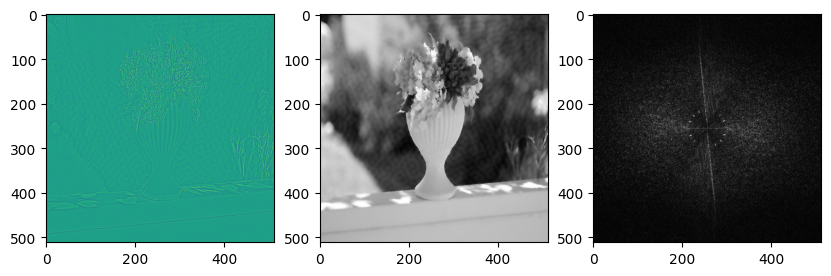

In [38]:
from scipy.signal import wiener
from numpy.fft import fft2, fftshift
import numpy as np
import matplotlib.pyplot as plt
import cv2
newing=cv2.cvtColor(watermarked_image, cv2.COLOR_RGB2YUV)
newing=newing[:,:,0].astype(np.float32)
isimg=wiener(newing,mysize=(5,5)).astype(np.float32)
img=newing-isimg
cv2.imwrite("img.png", img.astype(np.uint8))
fftimg=np.abs(fftshift(fft2(img.astype(np.float32))))
# fftimg=20*np.log(fftimg+1e-10)
fftimg=cv2.normalize(fftimg, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
cv2.imwrite("fftimg.png", fftimg.astype(np.uint8))
plt.figure(figsize=(10,10))
ax=plt.subplot(1,3,1)
ax.imshow(img)
ax=plt.subplot(1,3,2)
ax.imshow(isimg,cmap='gray')
ax=plt.subplot(1,3,3)
ax.imshow(fftimg,cmap='gray')
plt.show()